# Descriptive Statistics

This chapter summarizes the statistical properties of the dataset using descriptive measures and distribution analyses.


In [1]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("../data/raw").resolve()

csv_file = DATA_RAW / "Turkish maqam music pieces in time series format_3000 rows x 365 columns.csv"

df = pd.read_csv(csv_file)

X = df.iloc[:, 1:]

print("Shape:", X.shape)

Shape: (3000, 365)


In [2]:
print("Global Mean   :", round(X.stack().mean(), 2))
print("Global Median :", round(X.stack().median(), 2))
print("Global Std    :", round(X.stack().std(), 2))
print("Global Min    :", X.min().min())
print("Global Max    :", X.max().max())

Global Mean   : 325.29
Global Median : 327.0
Global Std    : 22.45
Global Min    : 0.0
Global Max    : 402.0


In [3]:
piece_means = X.mean(axis=1)

piece_means.describe()

count    3000.000000
mean      325.334495
std         8.178026
min       289.487671
25%       320.017123
50%       325.537960
75%       331.137124
max       354.923288
dtype: float64

Number of pieces: 3000
Minimum mean pitch: 289.4876712328767
Maximum mean pitch: 354.92328767123286
Mean  : 325.33449485537153
Median: 325.5379597283825


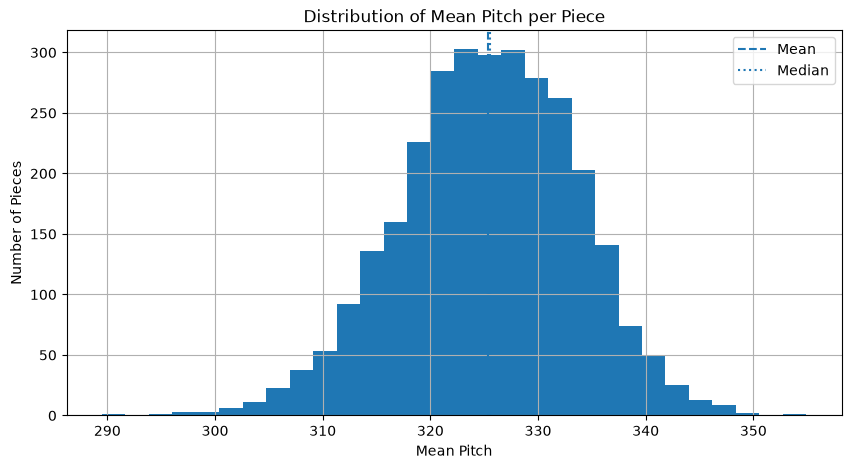

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(piece_means, bins=30)

plt.title("Distribution of Mean Pitch per Piece")
plt.xlabel("Mean Pitch")
plt.ylabel("Number of Pieces")
print("Number of pieces:", len(piece_means))
print("Minimum mean pitch:", piece_means.min())
print("Maximum mean pitch:", piece_means.max())
plt.axvline(piece_means.mean(), linestyle="--", label="Mean")
plt.axvline(piece_means.median(), linestyle=":", label="Median")
print("Mean  :", piece_means.mean())
print("Median:", piece_means.median())
plt.legend()
plt.grid(True)
plt.show()

In [5]:
piece_variances = X.var(axis=1)

piece_variances.describe()

count    3000.000000
mean      435.237686
std       259.467586
min        34.616901
25%       248.752011
50%       360.911748
75%       559.372829
max      2110.490095
dtype: float64

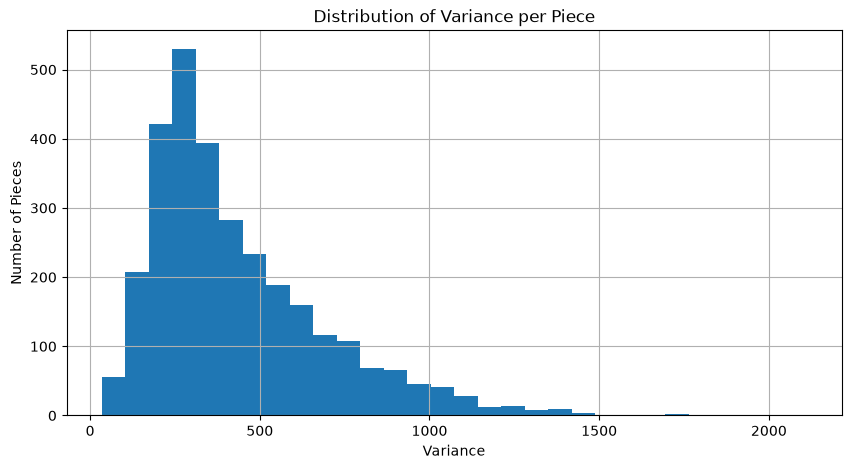

In [6]:
plt.figure(figsize=(10,5))

plt.hist(piece_variances, bins=30)

plt.title("Distribution of Variance per Piece")
plt.xlabel("Variance")
plt.ylabel("Number of Pieces")

plt.grid(True)
plt.show()

In [7]:
top_mean = piece_means.nlargest(10)

top_mean

1625    354.923288
2560    349.288184
1713    348.427778
1702    347.516575
1056    347.208219
1635    347.043836
249     346.769863
1634    346.752874
1205    346.356164
1029    346.263014
dtype: float64

In [8]:
low_mean = piece_means.nsmallest(10)

low_mean

453     289.487671
2295    295.671233
1244    297.076712
1240    297.136986
688     298.175342
445     299.635616
2603    300.132768
2134    300.260274
2015    300.421918
487     300.613699
dtype: float64

In [9]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Pieces",
        "Time Steps",
        "Missing Values",
        "Global Mean",
        "Global Median",
        "Global Std"
    ],
    "Value": [
        len(df),
        X.shape[1],
        df.isnull().sum().sum(),
        round(X.stack().mean(), 2),
        round(X.stack().median(), 2),
        round(X.stack().std(), 2)
    ]
})

summary

,Metric,Value
0,Number of Pieces,3000.00
1,Time Steps,365.00
2,Missing Values,20293.00
3,Global Mean,325.29
4,Global Median,327.00
5,Global Std,22.45
